As part of Lab 3, students are required to explore using a dataset of their choice. The selected dataset must contain and , including both .
Select or create a suitable dataset with numeric and nominal features.Perform basic data preprocessing:
* Handle missing values
* Encode categorical variables
* Apply feature scaling if required

Split the dataset into training and testing sets.

Build a Linear Regression model.Evaluate the model using:
* Mean Absolute Error (MAE)
* Mean Squared Error (MSE)
* Root Mean Squared Error (RMSE)
* R² Score

Analyze the concept of by comparing training and testing performance.Explain whether the model is generalized or overfitted.Suggest possible methods to reduce overfitting, such as:
* Feature selection
* Cross-validation
* Removing irrelevant variables

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

**Loading the dataset**

In [49]:
data = pd.read_csv("House Price Prediction Dataset.csv")

**General inspection**

In [50]:
print("Shape of Dataset:", data.shape)

data.head()

Shape of Dataset: (2000, 10)


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [51]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [52]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,2000.0,1000.5000,577.494589,1.0,500.75,1000.5,1500.25,2000.0
Area,2000.0,2786.2095,1295.146799,501.0,1653.00,2833.0,3887.50,4999.0
Bedrooms,2000.0,3.0035,1.424606,1.0,2.00,3.0,4.00,5.0
Bathrooms,2000.0,2.5525,1.108990,1.0,2.00,3.0,4.00,4.0
Floors,2000.0,1.9935,0.809188,1.0,1.00,2.0,3.00,3.0
YearBuilt,2000.0,1961.4460,35.926695,1900.0,1930.00,1961.0,1993.00,2023.0
Price,2000.0,537676.8550,276428.845719,50005.0,300098.00,539254.0,780086.00,999656.0


**Check for missing values**

In [53]:
data.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

**Check for duplicate records**

In [54]:
print("Duplicates before:", data.duplicated().sum())

data.drop_duplicates(inplace=True)

print("Duplicates after:", data.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


**Remove unneccessary columns**

In [55]:
data.drop('Id', axis=1, inplace=True)

In [56]:
data.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3592,2,2,3,1938,Downtown,Good,No,266746
3,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,4926,1,4,2,1975,Downtown,Fair,Yes,636056


**Data exploration**

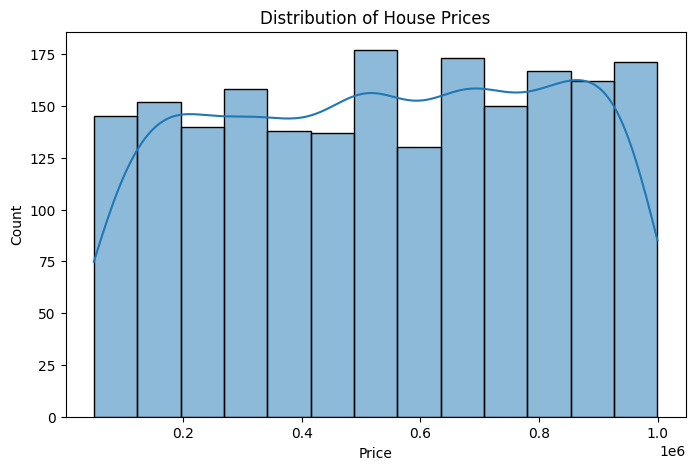

In [57]:
# checking the distribution of the target variable
plt.figure(figsize=(8,5))

sns.histplot(data['Price'], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.show()

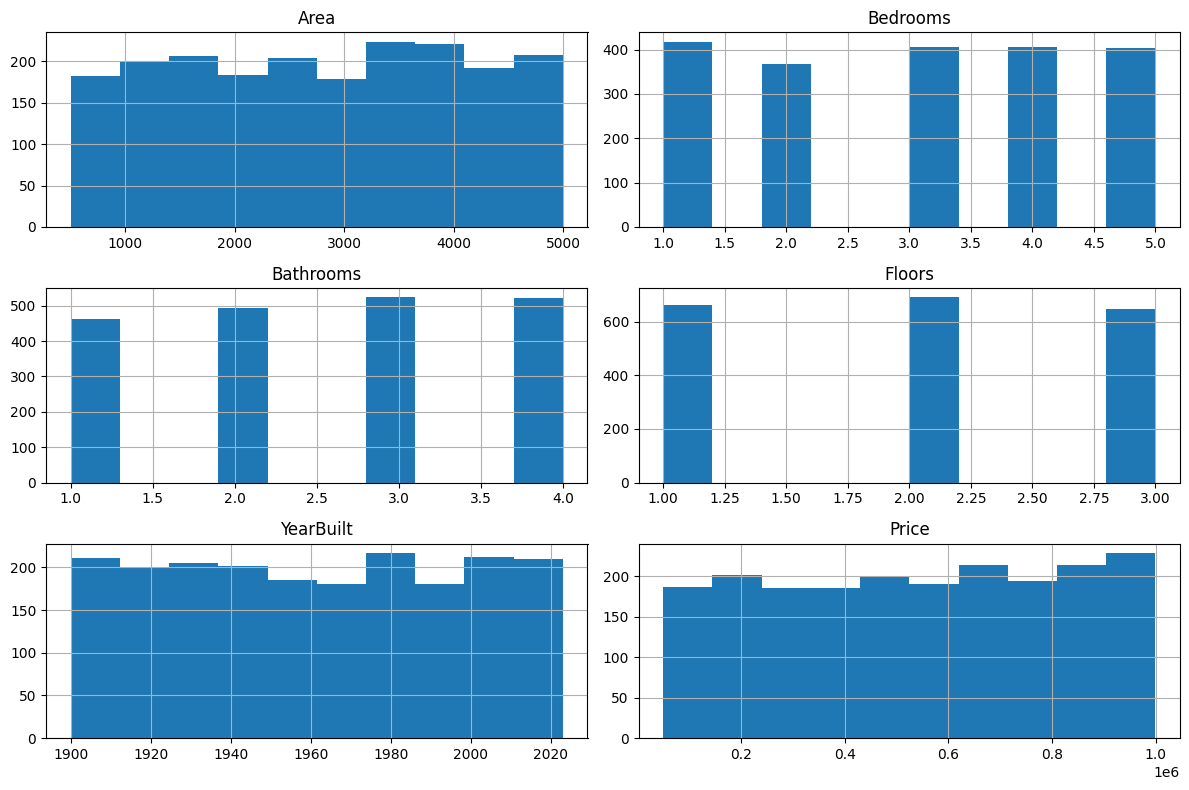

In [58]:
# checking distribution of numerical features

num_cols = [
    'Area',
    'Bedrooms',
    'Bathrooms',
    'Floors',
    'YearBuilt',
    'Price'
]

data[num_cols].hist(figsize=(12,8))

plt.tight_layout()
plt.show()

**Outlier detection**

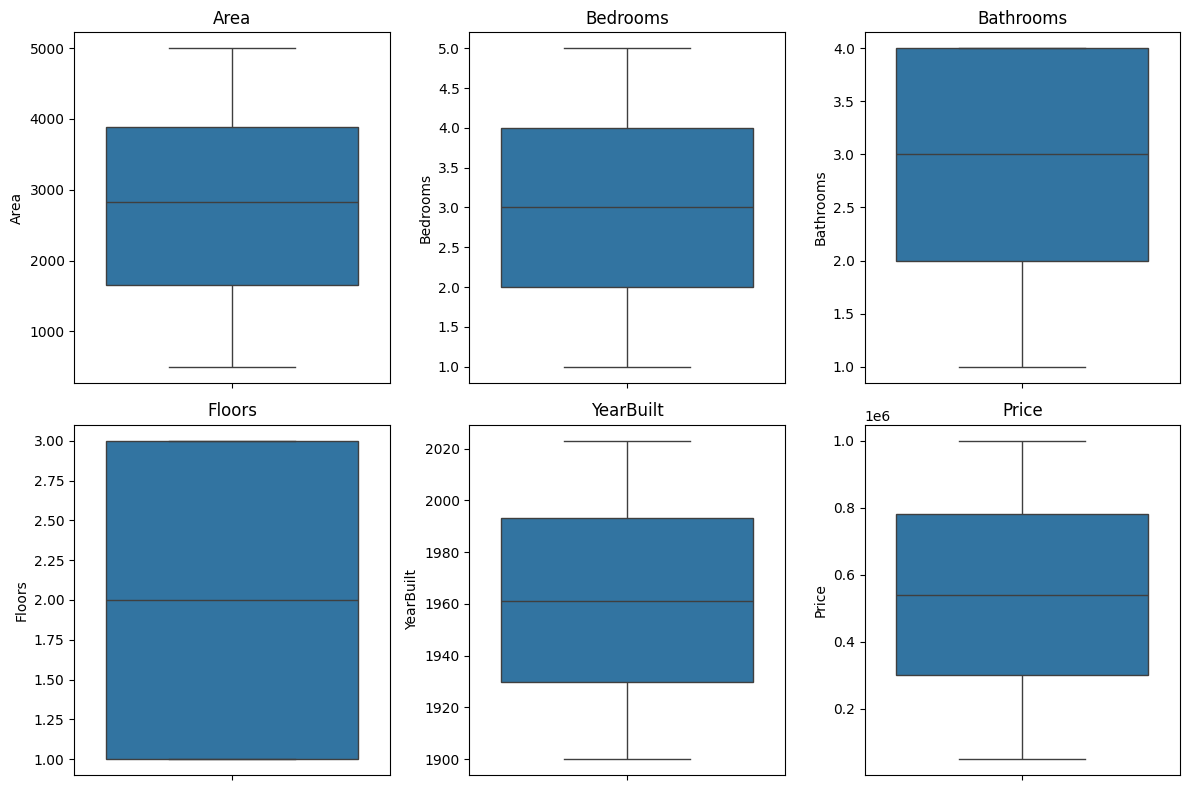

In [59]:
plt.figure(figsize=(12,8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2,3,i)
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [60]:
for col in num_cols:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[col] < lower) |
        (data[col] > upper)
    ]

    print(f"{col}: {len(outliers)} outliers")

Area: 0 outliers
Bedrooms: 0 outliers
Bathrooms: 0 outliers
Floors: 0 outliers
YearBuilt: 0 outliers
Price: 0 outliers


**Data encoding**

In [61]:
# checking distribution of categorical features

cat_cols = ['Location', 'Condition', 'Garage']

for col in cat_cols:
    print(f"\n{col}")
    print(data[col].value_counts())



Location
Location
Downtown    558
Urban       485
Suburban    483
Rural       474
Name: count, dtype: int64

Condition
Condition
Fair         521
Excellent    511
Poor         507
Good         461
Name: count, dtype: int64

Garage
Garage
No     1038
Yes     962
Name: count, dtype: int64


In [62]:
# use one-hot encoding for categorical features

data = pd.get_dummies(
    data,
    columns=['Location', 'Condition', 'Garage'],
    drop_first=True
)

In [63]:
data.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1360,5,4,3,1970,149919,False,False,False,False,False,False,False
1,4272,5,4,3,1958,424998,False,False,False,False,False,False,False
2,3592,2,2,3,1938,266746,False,False,False,False,True,False,False
3,966,4,2,2,1902,244020,False,True,False,True,False,False,True
4,4926,1,4,2,1975,636056,False,False,False,True,False,False,True


In [64]:
# converting true/false values to 1/0

bool_cols = data.select_dtypes(include='bool').columns

data[bool_cols] = data[bool_cols].astype(int)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Area               2000 non-null   int64
 1   Bedrooms           2000 non-null   int64
 2   Bathrooms          2000 non-null   int64
 3   Floors             2000 non-null   int64
 4   YearBuilt          2000 non-null   int64
 5   Price              2000 non-null   int64
 6   Location_Rural     2000 non-null   int64
 7   Location_Suburban  2000 non-null   int64
 8   Location_Urban     2000 non-null   int64
 9   Condition_Fair     2000 non-null   int64
 10  Condition_Good     2000 non-null   int64
 11  Condition_Poor     2000 non-null   int64
 12  Garage_Yes         2000 non-null   int64
dtypes: int64(13)
memory usage: 203.2 KB


**Linear regression**

In [65]:
X = data[['Area']]
y = data['Price']

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [67]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [68]:
model = LinearRegression()

model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [69]:
area_price_slope = model.coef_[0]
area_price_intercept = model.intercept_

print("Slope:", area_price_slope)
print("Intercept:", area_price_intercept)

Slope: -239.15542615736635
Intercept: 536183.7


In [70]:
y_pred = model.predict(X_test_scaled)

In [71]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 242478.32249473498
MSE : 77856127383.1798
RMSE: 279027.1086887075
R²  : -0.0007365003351658128


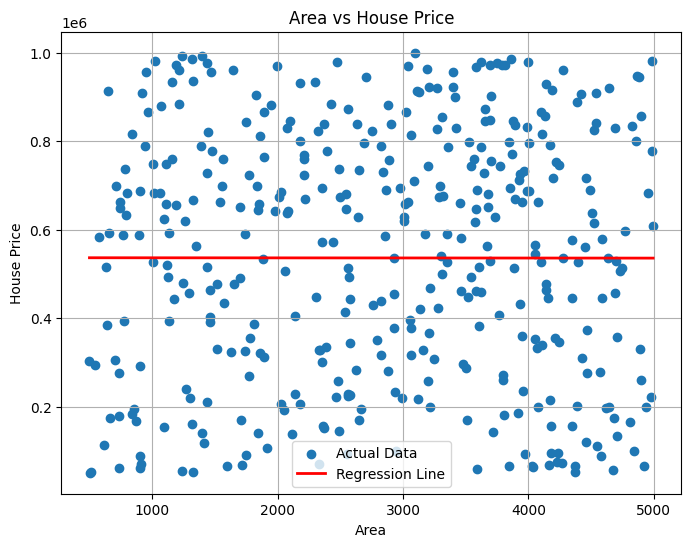

In [72]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

plt.scatter(X_test, y_test, label='Actual Data')

# Sort values for a smooth regression line
sorted_idx = np.argsort(X_test.values.flatten())

plt.plot(
    X_test.values.flatten()[sorted_idx],
    y_pred[sorted_idx],
    color='red',
    linewidth=2,
    label='Regression Line'
)

plt.title("Area vs House Price")
plt.xlabel("Area")
plt.ylabel("House Price")
plt.legend()
plt.grid(True)

plt.show()

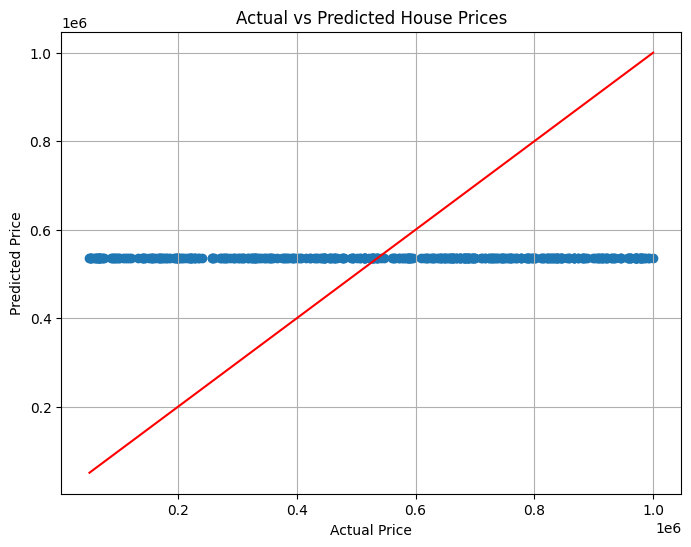

In [73]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.grid(True)
plt.show()

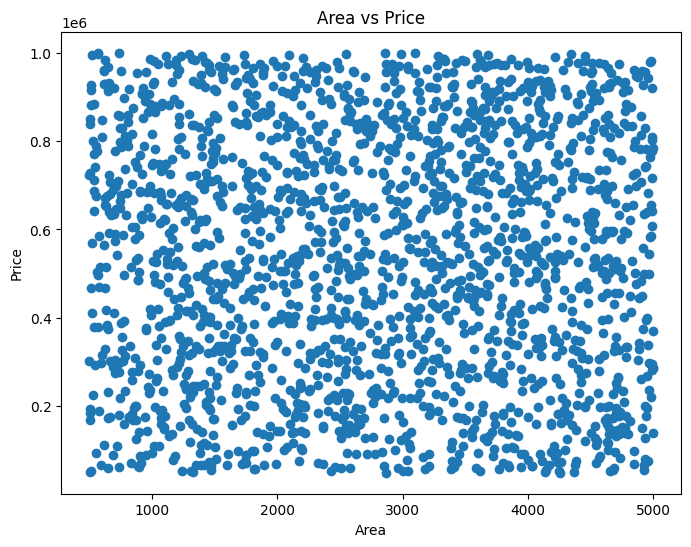

In [74]:
plt.figure(figsize=(8,6))

plt.scatter(data['Area'], data['Price'])

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")

plt.show()

In [75]:
print(data[['Area','Price']].corr())

           Area     Price
Area   1.000000  0.001542
Price  0.001542  1.000000


In [76]:
data.corr()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
Area,1.000000,0.047523,0.021881,0.017749,-0.011609,0.001542,-0.017328,0.003404,0.000010,0.012805,0.001289,-0.003387,-0.003441
Bedrooms,0.047523,1.000000,-0.011990,0.010435,-0.014125,-0.003471,-0.011276,-0.010409,0.025640,0.002541,-0.008847,0.010673,-0.041713
Bathrooms,0.021881,-0.011990,1.000000,0.029089,-0.000839,-0.015737,-0.020028,-0.000904,-0.007326,-0.029646,0.021735,0.013355,0.004057
Floors,0.017749,0.010435,0.029089,1.000000,-0.006474,0.055890,-0.007149,-0.009907,0.014640,-0.000864,0.001462,0.017469,-0.004635
YearBuilt,-0.011609,-0.014125,-0.000839,-0.006474,1.000000,0.004845,-0.009179,-0.004632,-0.029859,-0.039087,0.022457,0.020892,-0.011703
Price,0.001542,-0.003471,-0.015737,0.055890,0.004845,1.000000,0.001890,0.040303,-0.038312,0.049218,-0.017179,-0.018437,0.002842
Location_Rural,-0.017328,-0.011276,-0.020028,-0.007149,-0.009179,0.001890,1.000000,-0.314480,-0.315338,0.022832,-0.025844,0.004976,0.028254
Location_Suburban,0.003404,-0.010409,-0.000904,-0.009907,-0.004632,0.040303,-0.314480,1.000000,-0.319261,0.003137,-0.000920,0.001503,0.027303
Location_Urban,0.000010,0.025640,-0.007326,0.014640,-0.029859,-0.038312,-0.315338,-0.319261,1.000000,-0.003568,0.006115,0.018913,-0.010005
Condition_Fair,0.012805,0.002541,-0.029646,-0.000864,-0.039087,0.049218,0.022832,0.003137,-0.003568,1.000000,-0.324837,-0.345867,0.021430


In [77]:
corr = data.corr(numeric_only=True)

print(corr['Price'].sort_values(ascending=False))

Price                1.000000
Floors               0.055890
Condition_Fair       0.049218
Location_Suburban    0.040303
YearBuilt            0.004845
Garage_Yes           0.002842
Location_Rural       0.001890
Area                 0.001542
Bedrooms            -0.003471
Bathrooms           -0.015737
Condition_Good      -0.017179
Condition_Poor      -0.018437
Location_Urban      -0.038312
Name: Price, dtype: float64
